# 02 – Feature-Engineering: einheitliche Feature-Matrix (Baumärkte)

Erzeugt `data/processed/features.parquet` als gemeinsame Datenbasis für alle
nachfolgenden Methoden (Z-Score-Baseline, ARIMA, Isolation-Forest-Vergleich).

Aufbau: Laden + Zähler-Filter → Zeitzonen/Stundenraster vereinheitlichen →
Kalender-/Wetter-/Preis-/Lag-Features → **STL**-Saisonalzerlegung →
Join + Output + Befunde zur Wetter↔Verbrauch-Korrelation.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from statsmodels.tsa.seasonal import STL

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eda import loader  # noqa: E402

ABB = ROOT / "docs" / "konzept" / "abbildungen"
ABB.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"
TZ = "Europe/Berlin"

plt.rcParams.update(
    {"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3}
)


def savefig(fig, name: str) -> None:
    fig.tight_layout()
    fig.savefig(ABB / name, dpi=150, bbox_inches="tight")
    print("gespeichert:", name)

## 1. Daten laden & Zähler-Filter

In [2]:
df = loader.load_category("Baumärkte")

# Flache Zähler ausschließen (vmax < 1 kW), Schwelle aus der EDA.
vmax = df.groupby(level="meter_id")["value_kw"].max()
flat_ids = sorted(vmax[vmax < 1.0].index)
solid_ids = sorted(vmax[vmax >= 1.0].index)
df = df.loc[solid_ids]

print(f"Solide Zähler: {len(solid_ids)} | ausgeschlossen (flach): {flat_ids}")

weather = pd.read_parquet(PROCESSED / "weather.parquet")
prices = pd.read_parquet(PROCESSED / "prices.parquet")
print("weather:", weather.shape, "| prices:", prices.shape)

Solide Zähler: 23 | ausgeschlossen (flach): ['Baumarkt_01', 'Baumarkt_02', 'Baumarkt_04']
weather: (28033, 20) | prices: (39843, 1)


**Zähler-Filter (für den Methodik-Teil des Papers).** Ausgeschlossen werden die in der
EDA (`01_eda.ipynb`, Block 2b) identifizierten **flachen Zähler** mit Maximalwert
< 1 kW: `Baumarkt_01`, `Baumarkt_02`, `Baumarkt_04`. Vermutlich Einheiten-Bug (W statt
kW) oder Unterzähler — **mit Marja zu klären**, vorerst aus der Hauptanalyse heraus
(nicht gelöscht). Es verbleiben 23 solide Zähler.

## 2. Zeitzonen vereinheitlichen & gemeinsames Stundenraster

Smart-Meter ist bereits `Europe/Berlin` (durch den Loader). Wetter und Preise liegen in
UTC → auf `Europe/Berlin` konvertieren, dann alles auf **1 h** bringen. Die EPEX-Reihe
ist bis 2024 stündlich, ab 2025 viertelstündlich; `resample("1h").mean()` vereinheitlicht
beides (kein separates forward-fill nötig, da wir nicht hochsampeln).

In [3]:
weather = weather.tz_convert(TZ)
prices = prices.tz_convert(TZ)

# Wetter ist stündlich; zur Sicherheit auf sauberes 1h-Raster bringen.
weather_h = weather.resample("1h").mean(numeric_only=True)
# Preise auf gemeinsame Stundenfrequenz (löst die gemischte Granularität).
price_h = prices["price_eur_mwh"].resample("1h").mean()

# Smart-Meter (Leistung kW) pro Zähler auf Stundenmittel.
sm_h = (
    df["value_kw"]
    .groupby(level="meter_id")
    .resample("1h", level="timestamp")
    .mean()
)
print("Stunden-Smart-Meter:", sm_h.shape, "| weather_h:", weather_h.shape, "| price_h:", price_h.shape)

Stunden-Smart-Meter: (557280,) | weather_h: (28033, 15) | price_h: (28032,)


## 3. STL-Saisonalzerlegung pro Zähler

**STL** (Seasonal-Trend decomposition using LOESS, Cleveland et al. 1990) mit
`period=168` (wöchentliche Saison auf Stundendaten; der 168er-Zyklus enthält die
Tagesform). Vorteile gegenüber einem (dow, hour)-Mittel: explizite **Trend**-Komponente
(über 3 Jahre relevant), **robust** gegen Ausreißer (LOESS), und **zitierbare**
Lehrbuchmethode. Wir legen `trend`, `seasonal` und `resid` ab; `resid` ist der Input für
die Z-Score-Baseline, `trend` halten wir für die spätere ARIMA-Diskussion vor.

Für STL muss die Reihe lückenlos sein → pro Zähler auf das volle Stundenraster
reindexen und kurze Lücken interpolieren (`is_imputed` markiert das).

> **Leakage-Hinweis:** Die STL läuft hier über die volle Historie (Exploration/Features).
> Für die spätere **Modellbewertung** wird zeitlich gesplittet (kein Shuffling).

In [4]:
parts = []
for mid, g in sm_h.groupby(level="meter_id"):
    s = g.droplevel("meter_id").sort_index()
    full = pd.date_range(s.index.min(), s.index.max(), freq="1h", tz=s.index.tz)
    s = s.reindex(full)
    is_imp = s.isna()
    s = s.interpolate(limit=24).ffill().bfill()  # lückenlos für STL
    res = STL(s, period=168, robust=True).fit()
    part = pd.DataFrame(
        {
            "value_kw": s.to_numpy(),
            "is_imputed": is_imp.to_numpy(),
            "stl_trend": res.trend.to_numpy(),
            "stl_seasonal": res.seasonal.to_numpy(),
            "stl_resid": res.resid.to_numpy(),
        },
        index=pd.MultiIndex.from_product([[mid], full], names=["meter_id", "timestamp"]),
    )
    parts.append(part)

feat = pd.concat(parts)
print("Feature-Gerüst:", feat.shape)
feat.head(3)

Feature-Gerüst: (557280, 5)


value_kw  is_imputed  stl_trend  \
meter_id    timestamp                                                    
Baumarkt_03 2023-01-01 00:00:00+01:00     10.40       False  39.384414   
            2023-01-01 01:00:00+01:00     11.80       False  39.397759   
            2023-01-01 02:00:00+01:00     10.65       False  39.411096   

                                       stl_seasonal  stl_resid  
meter_id    timestamp                                           
Baumarkt_03 2023-01-01 00:00:00+01:00    -28.210887  -0.773527  
            2023-01-01 01:00:00+01:00    -27.073939  -0.523821  
            2023-01-01 02:00:00+01:00    -28.496607  -0.264489

## 4. Kalender-Features inkl. Feiertage (national + alle 16 Bundesländer)

`is_holiday` = bundesweite Feiertage. Zusätzlich pro Bundesland `is_holiday_<XX>`, damit
nach dem Marja-Call (echte Standorte) ohne Neuberechnung umgeschaltet werden kann.

In [5]:
ts = feat.index.get_level_values("timestamp")
feat["hour"] = ts.hour
feat["dow"] = ts.dayofweek
feat["is_weekend"] = ts.dayofweek >= 5
feat["month"] = ts.month
feat["doy"] = ts.dayofyear

years = range(int(ts.year.min()), int(ts.year.max()) + 1)
STATES = ["BW", "BY", "BE", "BB", "HB", "HH", "HE", "MV",
          "NI", "NW", "RP", "SL", "SN", "ST", "SH", "TH"]

date_arr = ts.date  # datetime.date je Zeile
uniq = pd.unique(date_arr)

nat = holidays.Germany(years=years)
nat_map = {d: (d in nat) for d in uniq}
feat["is_holiday"] = [nat_map[d] for d in date_arr]

for st in STATES:
    hd = holidays.Germany(subdiv=st, years=years)
    st_map = {d: (d in hd) for d in uniq}
    feat[f"is_holiday_{st}"] = [st_map[d] for d in date_arr]

print("Kalender-Features ergänzt. Beispiel Feiertags-Spalten:",
      ["is_holiday"] + [f"is_holiday_{s}" for s in STATES[:3]], "...")

Kalender-Features ergänzt. Beispiel Feiertags-Spalten: ['is_holiday', 'is_holiday_BW', 'is_holiday_BY', 'is_holiday_BE'] ...


## 5. Wetter- und Preis-Features (inkl. Lags)

Auf den globalen Stundenreihen berechnet (gelten für alle Zähler), dann per Zeitstempel
gejoint. Verbrauchs-Lags dagegen **pro Zähler**.

In [6]:
# Wetter-Features
wf = pd.DataFrame(index=weather_h.index)
wf["temperature"] = weather_h["temperature"]
wf["hdd"] = weather_h["hdd"]
wf["temperature_lag_24h"] = wf["temperature"].shift(24)
wf["temperature_lag_48h"] = wf["temperature"].shift(48)

# Preis-Features
pf = pd.DataFrame(index=price_h.index)
pf["price_eur_mwh"] = price_h
pf["price_lag_24h"] = pf["price_eur_mwh"].shift(24)
pf["is_negative"] = pf["price_eur_mwh"] < 0

print("Wetter-Features:", list(wf.columns), "| Preis-Features:", list(pf.columns))

Wetter-Features: ['temperature', 'hdd', 'temperature_lag_24h', 'temperature_lag_48h'] | Preis-Features: ['price_eur_mwh', 'price_lag_24h', 'is_negative']


In [7]:
# Join globaler Wetter-/Preis-Features auf die timestamp-Ebene
feat = feat.join(wf, on="timestamp").join(pf, on="timestamp")

# Verbrauchs-Lags pro Zähler
feat["value_lag_24h"] = feat.groupby(level="meter_id")["value_kw"].shift(24)
feat["value_lag_168h"] = feat.groupby(level="meter_id")["value_kw"].shift(168)

print("Feature-Matrix:", feat.shape)
print("Spalten:", list(feat.columns))

Feature-Matrix: (557280, 36)
Spalten: ['value_kw', 'is_imputed', 'stl_trend', 'stl_seasonal', 'stl_resid', 'hour', 'dow', 'is_weekend', 'month', 'doy', 'is_holiday', 'is_holiday_BW', 'is_holiday_BY', 'is_holiday_BE', 'is_holiday_BB', 'is_holiday_HB', 'is_holiday_HH', 'is_holiday_HE', 'is_holiday_MV', 'is_holiday_NI', 'is_holiday_NW', 'is_holiday_RP', 'is_holiday_SL', 'is_holiday_SN', 'is_holiday_ST', 'is_holiday_SH', 'is_holiday_TH', 'temperature', 'hdd', 'temperature_lag_24h', 'temperature_lag_48h', 'price_eur_mwh', 'price_lag_24h', 'is_negative', 'value_lag_24h', 'value_lag_168h']


## 6. Output & Sanity-Check

In [8]:
out_path = PROCESSED / "features.parquet"
feat.to_parquet(out_path)
print("geschrieben:", out_path, "|", feat.shape)

# Zeit-Lücken pro Zähler (sollte 0 sein, da auf volles Stundenraster reindext)
gaps = 0
for mid, g in feat.groupby(level="meter_id"):
    idx = g.index.get_level_values("timestamp")
    full = pd.date_range(idx.min(), idx.max(), freq="1h", tz=idx.tz)
    gaps += len(full) - len(idx)
print("Zeit-Lücken im Stundenraster gesamt:", gaps)
print("Interpolierte (is_imputed) Zeilen:", int(feat["is_imputed"].sum()))

geschrieben: /Users/jakobringel/Projekt/datenwerkios-anomalie/data/processed/features.parquet | (557280, 36)
Zeit-Lücken im Stundenraster gesamt: 0
Interpolierte (is_imputed) Zeilen: 0


In [9]:
# Kurz-Profil pro Feature: dtype, min, max, mean, NaN-Anzahl
prof = pd.DataFrame(
    {
        "dtype": feat.dtypes.astype(str),
        "n_na": feat.isna().sum(),
        "min": feat.select_dtypes("number").min(),
        "max": feat.select_dtypes("number").max(),
        "mean": feat.select_dtypes("number").mean(),
    }
)
prof.round(2)

,dtype,n_na,min,max,mean
dow,int32,0,0.00,6.00,3.00
doy,int32,0,1.00,366.00,183.06
hdd,float64,19,0.00,26.20,5.50
hour,int32,0,0.00,23.00,11.50
is_holiday,bool,0,NaN,NaN,NaN
is_holiday_BB,bool,0,NaN,NaN,NaN
is_holiday_BE,bool,0,NaN,NaN,NaN
is_holiday_BW,bool,0,NaN,NaN,NaN
is_holiday_BY,bool,0,NaN,NaN,NaN
is_holiday_HB,bool,0,NaN,NaN,NaN


NaN tritt erwartungsgemäß nur in den **Lag-Spalten** am Reihenanfang auf
(24 h / 48 h / 168 h Warmup) sowie ggf. in Wetter-Lags vor dem ersten verfügbaren
Wetterzeitpunkt. Die Zeilen bleiben erhalten; nachgelagerte Methoden droppen NaN nach
Bedarf.

## 7. Plots & Befunde: Wetter ↔ Verbrauch

Repräsentativer Zähler: Baumarkt_06
gespeichert: features_residual_verteilung.png


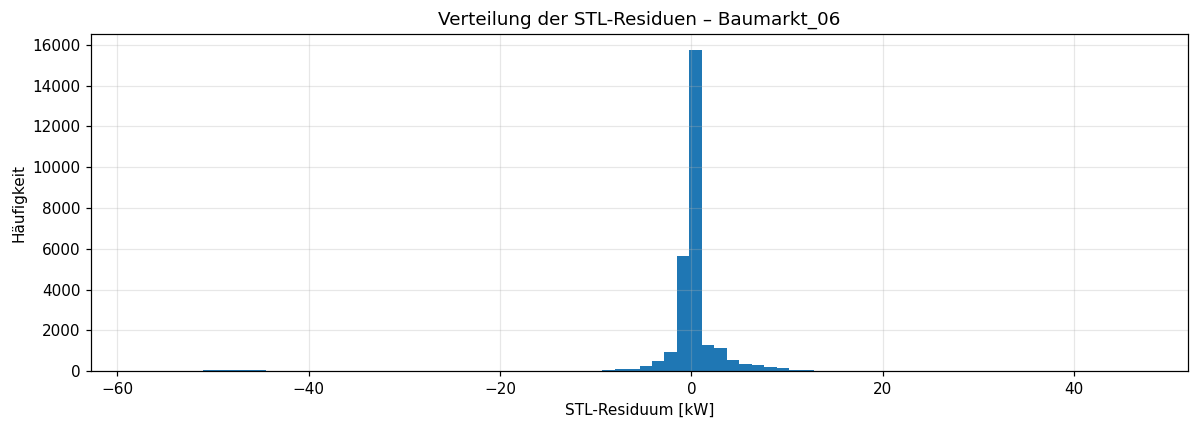

In [10]:
REP = feat.groupby(level="meter_id").size().idxmax()
rep = feat.xs(REP, level="meter_id")
print("Repräsentativer Zähler:", REP)

# STL-Residuen-Verteilung
fig, ax = plt.subplots()
ax.hist(rep["stl_resid"].dropna(), bins=80)
ax.set_title(f"Verteilung der STL-Residuen – {REP}")
ax.set_xlabel("STL-Residuum [kW]")
ax.set_ylabel("Häufigkeit")
savefig(fig, "features_residual_verteilung.png")
plt.show()

gespeichert: features_wetter_verbrauch_korrelation.png


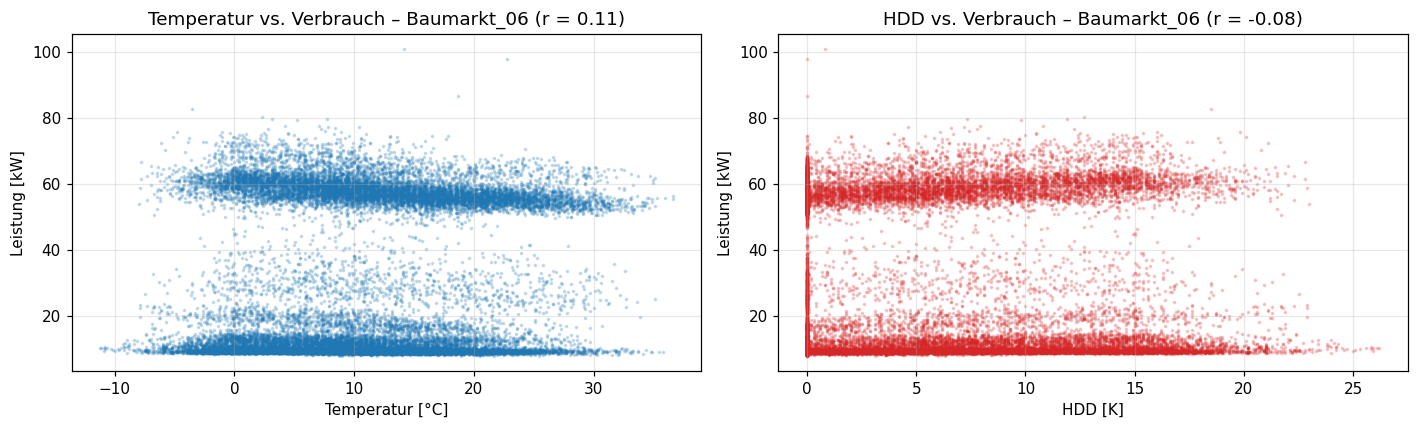

Korrelation Temperatur↔Verbrauch: r = 0.113
Korrelation HDD↔Verbrauch:        r = -0.075


In [11]:
# Temperatur vs. Verbrauch (stündlich, repräsentativer Zähler) + Korrelation
sub = rep[["value_kw", "temperature", "hdd"]].dropna()
r_temp = sub["value_kw"].corr(sub["temperature"])
r_hdd = sub["value_kw"].corr(sub["hdd"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(sub["temperature"], sub["value_kw"], s=2, alpha=0.2)
axes[0].set_title(f"Temperatur vs. Verbrauch – {REP} (r = {r_temp:.2f})")
axes[0].set_xlabel("Temperatur [°C]")
axes[0].set_ylabel("Leistung [kW]")
axes[1].scatter(sub["hdd"], sub["value_kw"], s=2, alpha=0.2, color="tab:red")
axes[1].set_title(f"HDD vs. Verbrauch – {REP} (r = {r_hdd:.2f})")
axes[1].set_xlabel("HDD [K]")
axes[1].set_ylabel("Leistung [kW]")
savefig(fig, "features_wetter_verbrauch_korrelation.png")
plt.show()

print(f"Korrelation Temperatur↔Verbrauch: r = {r_temp:.3f}")
print(f"Korrelation HDD↔Verbrauch:        r = {r_hdd:.3f}")

gespeichert: features_temp_korrelation_je_zaehler.png


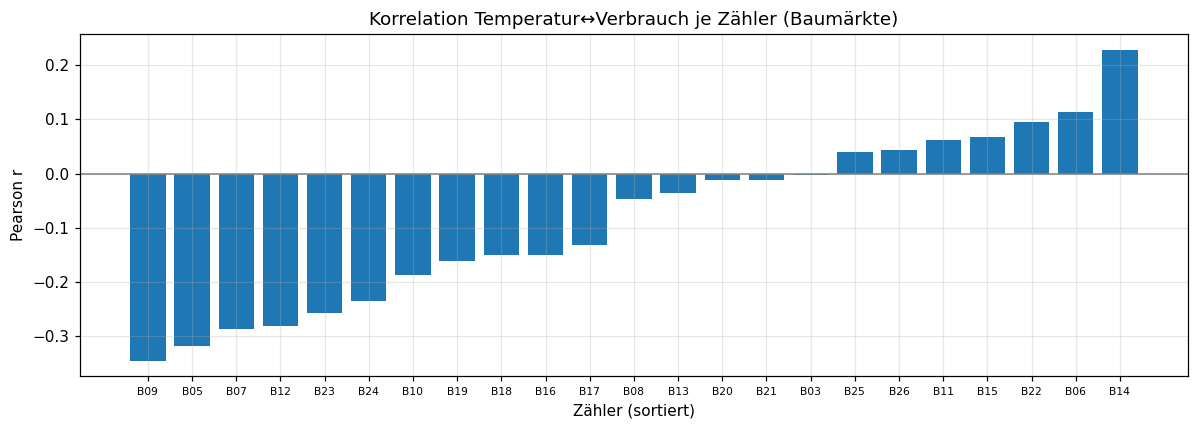

r-Spanne über Zähler: -0.34 bis 0.23


In [12]:
# Korrelation Temperatur↔Verbrauch über alle soliden Zähler (Verteilung der r-Werte)
corrs = {}
for mid, g in feat.groupby(level="meter_id"):
    s = g[["value_kw", "temperature"]].dropna()
    corrs[mid] = s["value_kw"].corr(s["temperature"])
corr_s = pd.Series(corrs).sort_values()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(corr_s)), corr_s.values)
ax.axhline(0, color="grey", lw=1)
ax.set_title("Korrelation Temperatur↔Verbrauch je Zähler (Baumärkte)")
ax.set_xlabel("Zähler (sortiert)")
ax.set_ylabel("Pearson r")
ax.set_xticks(range(len(corr_s)))
ax.set_xticklabels([m.replace("Baumarkt_", "B") for m in corr_s.index], fontsize=7)
savefig(fig, "features_temp_korrelation_je_zaehler.png")
plt.show()
print("r-Spanne über Zähler:", round(corr_s.min(), 2), "bis", round(corr_s.max(), 2))

gespeichert: features_temp_korrelation_tagesmittel.png


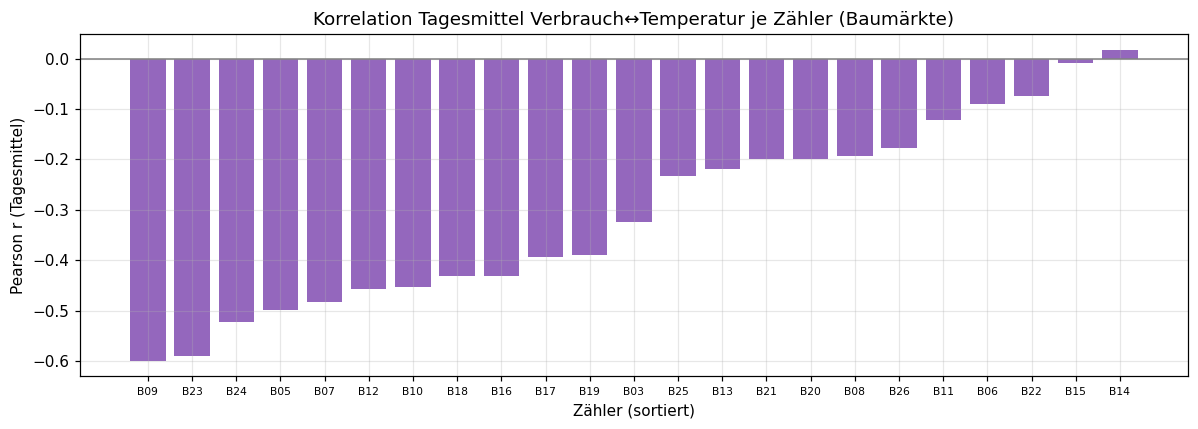

Tagesmittel value~temp: median r=-0.324 (-0.60..0.02), negativ bei 22/23 Zählern
STL-Residuum~temp (stündlich): median r=0.018 (-0.04..0.07)


In [13]:
# Fairerer Wetter-Test: Tagesaggregate (Tageszyklus herausgemittelt) und STL-Residuum
daily_r, resid_r = {}, {}
for mid, g in feat.groupby(level="meter_id"):
    g = g.droplevel("meter_id")
    d = g[["value_kw", "temperature"]].resample("1D").mean().dropna()
    daily_r[mid] = d["value_kw"].corr(d["temperature"])
    s = g[["stl_resid", "temperature"]].dropna()
    resid_r[mid] = s["stl_resid"].corr(s["temperature"])
daily_r = pd.Series(daily_r).sort_values()
resid_r = pd.Series(resid_r)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(daily_r)), daily_r.values, color="tab:purple")
ax.axhline(0, color="grey", lw=1)
ax.set_title("Korrelation Tagesmittel Verbrauch↔Temperatur je Zähler (Baumärkte)")
ax.set_xlabel("Zähler (sortiert)")
ax.set_ylabel("Pearson r (Tagesmittel)")
ax.set_xticks(range(len(daily_r)))
ax.set_xticklabels([m.replace("Baumarkt_", "B") for m in daily_r.index], fontsize=7)
savefig(fig, "features_temp_korrelation_tagesmittel.png")
plt.show()

print("Tagesmittel value~temp: median r=%.3f (%.2f..%.2f), negativ bei %d/%d Zählern"
      % (daily_r.median(), daily_r.min(), daily_r.max(), (daily_r < 0).sum(), len(daily_r)))
print("STL-Residuum~temp (stündlich): median r=%.3f (%.2f..%.2f)"
      % (resid_r.median(), resid_r.min(), resid_r.max()))

## 8. Befunde zur Korrelation Wetter ↔ Verbrauch (für die Methodik)

Drei Auflösungen, drei Bilder — und genau der Unterschied ist der methodisch
entscheidende Punkt:

- **Stündlich, roh:** Temperatur↔Verbrauch nur **r ≈ 0,11** (Baumarkt_06; über alle
  Zähler −0,34…0,23). Wirkt irrelevant — ist aber **artefaktisch**: der dominante
  Tages-/Wochenzyklus (Öffnungszeiten) überdeckt das Wettersignal.
- **Tagesmittel (Tageszyklus herausgemittelt):** **median r ≈ −0,32** (−0,60…0,02),
  **22 von 23 Zählern negativ**. Kältere Tage → höherer Verbrauch: ein klares,
  plausibles **Heizsignal**. Wetter ist also sehr wohl ein realer Treiber auf
  Tages-/Saisonebene.
- **STL-Residuum ↔ Temperatur:** **median r ≈ 0,02** (≈ 0). Die STL hat das Wettersignal
  bereits in **Trend + Saison absorbiert**; im Residuum bleibt praktisch nichts
  Wetterabhängiges.

**Konsequenzen für die Methodik:**

1. **Das STL-Residuum als Anomalie-Score ist weitgehend wetterunabhängig** — die
   Z-Score-Baseline auf dem Residuum braucht keine Wetterkorrektur (einfacher, erklärbar).
2. **Temperatur/HDD bleiben berechtigte Features** — für die Modellierung von Saison/Trend
   bzw. zur **Plausibilisierung** erkannter Anomalien („war es nur ein Kältetag?"), nicht
   als Hauptsignal.
3. Eine rein stündliche Korrelation hätte fälschlich „Wetter egal" suggeriert; erst die
   Aggregat-Analyse zeigt den Heizeffekt. Dieser Sorgfaltsschritt gehört in den
   Methodik-Teil.
4. Vorzeichen/Stärke variieren je Zähler → heterogene HVAC-Charakteristik, relevant für
   die Cluster-Argumentation.